## Exercise 0 - Iris flower dataset (*)

In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

### a, Check keys on iris loaded data to explore

In [40]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns= iris.feature_names)
df = pd.concat([df, pd.DataFrame(iris.target, columns= ["iris_species"])], axis = 1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [16]:
df.shape

(150, 5)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   iris_species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [24]:
import textwrap
print(textwrap.fill(iris.DESCR, width=90))

.. _iris_dataset:  Iris plants dataset --------------------  **Data Set Characteristics:**
:Number of Instances: 150 (50 in each of three classes) :Number of Attributes: 4 numeric,
predictive attributes and the class :Attribute Information:     - sepal length in cm     -
sepal width in cm     - petal length in cm     - petal width in cm     - class:
- Iris-Setosa             - Iris-Versicolour             - Iris-Virginica  :Summary
Statistics:  ============== ==== ==== ======= ===== ====================
Min  Max   Mean    SD   Class Correlation ============== ==== ==== ======= =====
==================== sepal length:   4.3  7.9   5.84   0.83    0.7826 sepal width:    2.0
4.4   3.05   0.43   -0.4194 petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!) ============== ==== ==== =======
===== ====================  :Missing Attribute Values: None :Class Distribution: 33.3% for
each of 3 classes. :Creator: R.A. Fisher :Donor: Mic

In [25]:
len(iris["feature_names"])

4

In [26]:
iris["target"].shape, iris["data"].shape

((150,), (150, 4))

In [32]:
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### b, After initial exploration of dataset, insert into DF
### c, Do EDA
### d, Make correlation heat map. Explore numbers

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [41]:
df["target"] = iris.target

In [42]:
# rename the numerical targets in legend
species_names = {0:"Setosa", 1:"Versicolor", 2:"Virginica"}
df["iris_species"] = df["target"].map(species_names)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

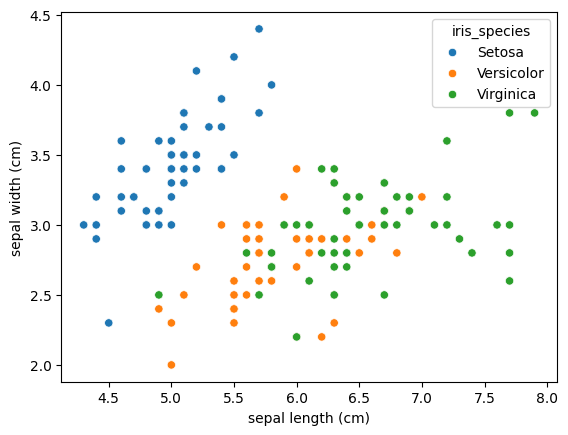

In [43]:
# heat map / scatter plot of how the features relate
sns.scatterplot(data=df, x= "sepal length (cm)", y= "sepal width (cm)", hue= "iris_species")

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

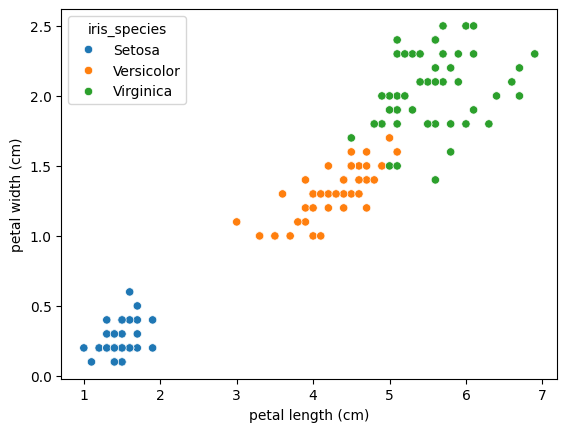

In [46]:
sns.scatterplot(data=df, x= "petal length (cm)", y= "petal width (cm)", hue= "iris_species")

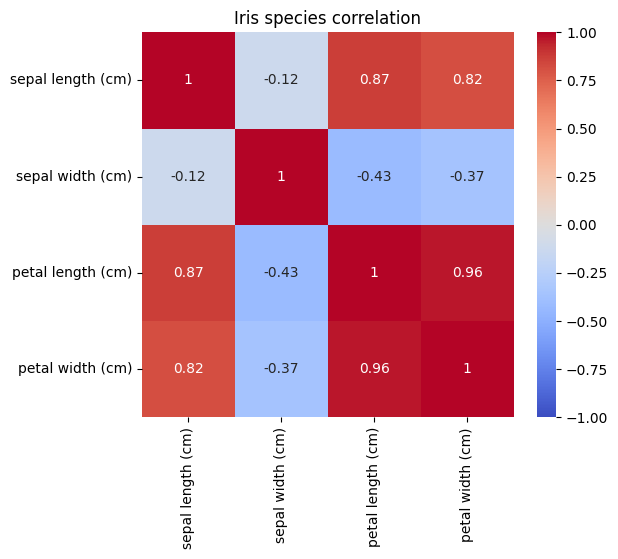

In [47]:
import matplotlib.pyplot as plt
import numpy as np

feature_columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
corr = df[feature_columns].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, vmin= -1, vmax= 1, center=0, cmap="coolwarm")
plt.title("Iris species correlation")
plt.show()

#### e, Create boxplot

<Axes: xlabel='iris_species', ylabel='sepal width (cm)'>

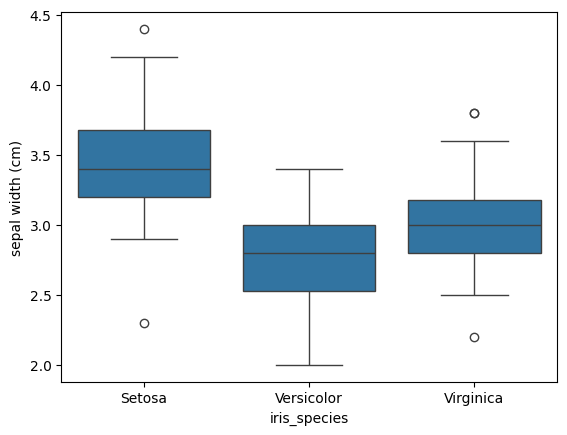

In [49]:
sns.boxplot(data=df, x="iris_species", y="sepal width (cm)", gap=0) #(hue="Species")

<Axes: >

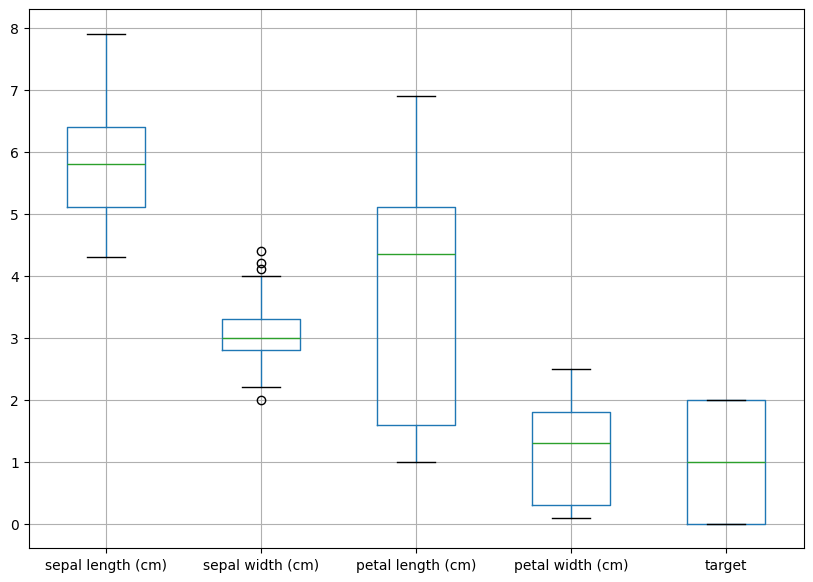

In [50]:
plt.figure(figsize=(10,7))
df.boxplot()

### f, Remove outliers in data from boxplot using Tukey's rule 
### lower bound outlier Q1 - 1.5 x IQR
### upper bound outlier Q3 + 1.5 x IQR
### IQR = Q3 - Q1

In [51]:
# pick features columns only:
feature_columns = df.select_dtypes(include=np.number).drop(columns=['target'], errors='ignore').columns
feature_columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [52]:
# compute IQR InterQuartile Range for lower and upper outliers of the dataset
# using Tukey's rule for boxplot 

Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - (1.5*IQR)
upper = Q3 + (1.5*IQR)

print(lower)
print(upper)

sepal length (cm)    3.15
sepal width (cm)     2.05
petal length (cm)   -3.65
petal width (cm)    -1.95
dtype: float64
sepal length (cm)     8.35
sepal width (cm)      4.05
petal length (cm)    10.35
petal width (cm)      4.05
dtype: float64


In [53]:
# keep only rows inside bounds:
inside_bounds = ((df[feature_columns] >= lower) & (df[feature_columns] <= upper))
inside_bounds.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True
4,True,True,True,True
5,True,True,True,True
6,True,True,True,True
7,True,True,True,True
8,True,True,True,True
9,True,True,True,True


### g, Do train|test split and scale using feature standardization